## Проект: вариант 1
Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

1. В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.
2. Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.
3. Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

## Задание 1

Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). Данные лежат в папке shared и имеют следующую структуру:

shared/problem1-reg_data.csv – данные о времени регистрации

shared/problem1-auth_data.csv – данные о времени захода пользователей в игру

Функция должна быть написана на python. В ходе решения можно тестировать работу функции как на полном датасете, так и на части (сэмпле) данных.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy.stats import chi2_contingency

In [2]:
reg_data = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-valentin-rotov-xgl8565/shared/problem1-reg_data.csv', sep=';')
auth_data = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-valentin-rotov-xgl8565/shared/problem1-auth_data.csv', sep=';')

/opt/conda/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [3]:
reg_data.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [4]:
auth_data.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [5]:
reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s')
auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s')

In [6]:
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   reg_ts  1000000 non-null  datetime64[ns]
 1   uid     1000000 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 15.3 MB


In [7]:
auth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype         
---  ------   -----         
 0   auth_ts  datetime64[ns]
 1   uid      int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 146.5 MB


In [8]:
auth_data_max = auth_data.groupby('uid', as_index = False).auth_ts.max()

In [9]:
auth_data_max

,uid,auth_ts
0,1,1998-11-18 09:43:43
1,2,2020-09-18 11:24:29
2,3,2000-01-13 22:27:27
3,4,2000-05-28 14:19:01
4,5,2000-09-16 11:21:53
...,...,...
999995,1110618,2020-09-23 15:13:54
999996,1110619,2020-09-23 15:14:46
999997,1110620,2020-09-23 15:15:39
999998,1110621,2020-09-23 15:16:31


In [10]:
retention_table = reg_data.merge(auth_data_max, how='left', on='uid').rename(columns={'auth_ts': 'last_auth'})

In [11]:
retention_table.head()

,reg_ts,uid,last_auth
0,1998-11-18 09:43:43,1,1998-11-18 09:43:43
1,1999-07-22 22:38:09,2,2020-09-18 11:24:29
2,2000-01-13 22:27:27,3,2000-01-13 22:27:27
3,2000-05-28 14:19:01,4,2000-05-28 14:19:01
4,2000-09-16 11:21:53,5,2000-09-16 11:21:53


In [12]:
retention_table['lifetime_days'] = (retention_table.last_auth.dt.date - retention_table.reg_ts.dt.date).dt.days

In [13]:
retention_table.head()

,reg_ts,uid,last_auth,lifetime_days
0,1998-11-18 09:43:43,1,1998-11-18 09:43:43,0
1,1999-07-22 22:38:09,2,2020-09-18 11:24:29,7729
2,2000-01-13 22:27:27,3,2000-01-13 22:27:27,0
3,2000-05-28 14:19:01,4,2000-05-28 14:19:01,0
4,2000-09-16 11:21:53,5,2000-09-16 11:21:53,0


In [14]:
retention_max_day = retention_table['lifetime_days'].max()

In [15]:
retention_table.lifetime_days.describe()

count    1000000.000000
mean          34.361845
std          188.139072
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max         7729.000000
Name: lifetime_days, dtype: float64

In [16]:
retention_table.lifetime_days.isna().sum()

0

In [17]:
total_users = len(retention_table)

In [18]:
retention = []
for d in range(retention_max_day + 1):
    cnt = (retention_table['lifetime_days'] >= d).sum()
    retention.append(cnt / total_users)

In [19]:
retention_series = pd.Series(retention, index=range(len(retention)))
retention_df = retention_series.reset_index()
retention_df.columns = ['day', 'retention']
retention_df

,day,retention
0,0,1.000000
1,1,0.238378
2,2,0.236689
3,3,0.233221
4,4,0.229280
...,...,...
7725,7725,0.000001
7726,7726,0.000001
7727,7727,0.000001
7728,7728,0.000001


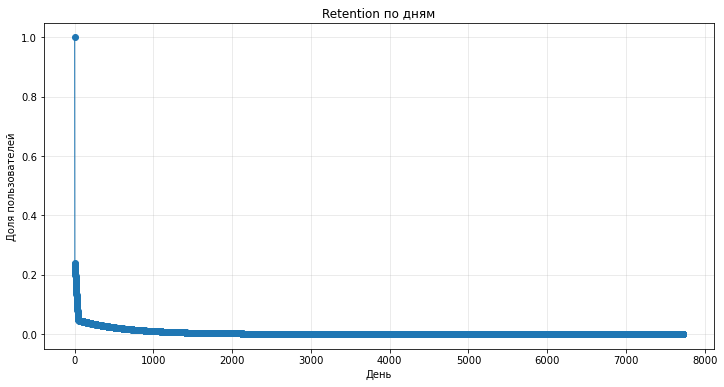

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(range(len(retention)), retention, marker='o', linestyle='-', linewidth=1)
plt.title('Retention по дням')
plt.xlabel('День')
plt.ylabel('Доля пользователей')
plt.grid(True, alpha=0.3)
plt.show()

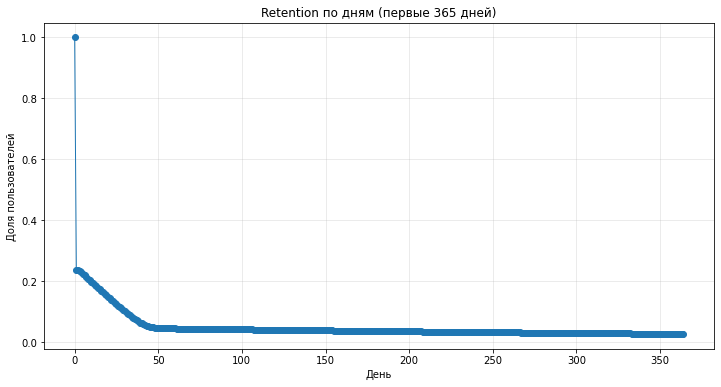

In [21]:
days_limit_365 = 365
retention_df = pd.DataFrame({
    'day': range(days_limit_365),
    'retention': retention[:days_limit_365]
})
plt.figure(figsize=(12, 6))
plt.plot(retention_df['day'], retention_df['retention'], marker='o', linestyle='-', linewidth=1)
plt.title('Retention по дням (первые 365 дней)')
plt.xlabel('День')
plt.ylabel('Доля пользователей')
plt.grid(True, alpha=0.3)
plt.show()

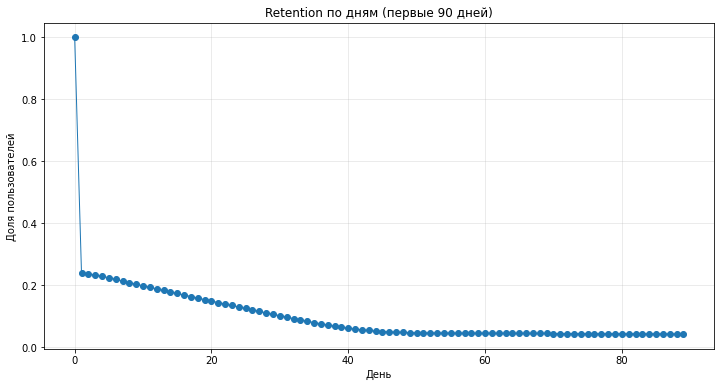

In [22]:
days_limit_90 = 90
retention_df = pd.DataFrame({
    'day': range(days_limit_90),
    'retention': retention[:days_limit_90]
})
plt.figure(figsize=(12, 6))
plt.plot(retention_df['day'], retention_df['retention'], marker='o', linestyle='-', linewidth=1)
plt.title('Retention по дням (первые 90 дней)')
plt.xlabel('День')
plt.ylabel('Доля пользователей')
plt.grid(True, alpha=0.3)
plt.show()

## Написание функции 

In [23]:
def retention_function (reg_data, auth_data, return_figures=True):
    # Читаем данные
    reg_data = pd.read_csv(reg_data, sep=';')
    auth_data = pd.read_csv(auth_data, sep=';')
    # Преобразуем в нормальную дату
    reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s')
    auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s')
    # Выделяем для каждого уникального айди последний заход в приложение
    auth_data_max = auth_data.groupby('uid', as_index = False).auth_ts.max()
    # Соединяем таблицы по последнему заходу и датой регистрации 
    retention_table = reg_data.merge(auth_data_max, how='left', on='uid').rename(columns={'auth_ts': 'last_auth'})
    # Начинаем считать ретеншен 
    retention_table['lifetime_days'] = (retention_table.last_auth.dt.date - retention_table.reg_ts.dt.date).dt.days
    retention_max_day = retention_table['lifetime_days'].max()
    total_users = len(retention_table)
    retention = []
    for d in range(retention_max_day + 1):
        cnt = (retention_table['lifetime_days'] >= d).sum()
        retention.append(cnt / total_users)
    retention_series = pd.Series(retention, index=range(len(retention)))
    retention_df = retention_series.reset_index()
    retention_df.columns = ['day', 'retention']
    # Ретеншен записан в retention_df
    # Покажем ретеншен наглядно в трех графиках:
    figures = []
    if return_figures:
        # 1. Полный график
        fig1, ax1 = plt.subplots(figsize=(12, 6))
        ax1.plot(range(len(retention)), retention, marker='o', linestyle='-', linewidth=1)
        ax1.set_title('Retention по дням')
        ax1.set_xlabel('День')
        ax1.set_ylabel('Доля пользователей')
        ax1.grid(True, alpha=0.3)
        figures.append(fig1)
        # 2. Первые 365 дней
        fig2, ax2 = plt.subplots(figsize=(12, 6))
        ax2.plot(range(365), retention[:365], marker='o', linestyle='-', linewidth=1)
        ax2.set_title('Retention по дням (первые 365 дней)')
        ax2.set_xlabel('День')
        ax2.set_ylabel('Доля пользователей')
        ax2.grid(True, alpha=0.3)
        figures.append(fig2)
        # 3. Первые 90 дней
        fig3, ax3 = plt.subplots(figsize=(12, 6))
        ax3.plot(range(90), retention[:90], marker='o', linestyle='-', linewidth=1)
        ax3.set_title('Retention по дням (первые 90 дней)')
        ax3.set_xlabel('День')
        ax3.set_ylabel('Доля пользователей')
        ax3.grid(True, alpha=0.3)
        figures.append(fig3)
    return retention_df, figures

## Задание 2
Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

In [24]:
# Записываю данные для исследования
project_1_test_2 = pd.read_csv('project_1_test_2.csv', sep=';')
project_1_test_2.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [25]:
# Определил контрольные и тестовые группы 
# control = a
control_group = project_1_test_2.query('testgroup == "a"')
describe_revenue_control_group =  control_group.query('revenue > 0').revenue.describe()

In [26]:
# test = b
test_group = project_1_test_2.query('testgroup == "b"')
describe_revenue_test_group = test_group.query('revenue > 0').revenue.describe()

In [27]:
# C помощью describe_revenue_control_group и describe_revenue_test_group описал выборки платящих клиентов в каждой группе. 
# Далее выделил основные метрики в контрольной и тестовой группе, а именно: 
# CR - доля платящих клиентов 
# ARPU - средняя выручка 
# ARPPU - средняя выручка на одного платящего клиента

In [28]:
CR_control = control_group.query('revenue > 0').user_id.count() / control_group.user_id.count()
ARPU_control =  control_group.revenue.mean()
ARPPU_control = control_group.query('revenue > 0').revenue.mean()
print (CR_control, ARPU_control, ARPPU_control)

0.009539690157988749 25.413719736965806 2663.9984439834025


In [29]:
CR_test = test_group.query('revenue > 0').user_id.count() / test_group.user_id.count()
ARPU_test =  test_group.revenue.mean()
ARPPU_test = test_group.query('revenue > 0').revenue.mean()
print (CR_test,ARPU_test,ARPPU_test)

0.008906235351586593 26.75128659327863 3003.6581717451522


In [30]:
# Выясняю, сколько в контрольной группе человек с чеком более 5000 revenue
control_group.query('revenue > 5000').user_id.count()
# 123

123

In [31]:
# Выясняю какая доля этих клиентов составляет в общей массе контрольной группы 
control_group.query('revenue > 5000').user_id.count() / control_group.query('revenue > 0').user_id.count() *100

6.379668049792531

In [32]:
# выясняю какая доля выручки от общей всей выручки идет именно от этих клиентов с чеком более 5000
control_group.query('revenue > 5000').revenue.sum() / control_group.revenue.sum() * 100

89.37077665950378

In [33]:
# подготовка для теста хи квадрат 
# Для контрольной группы
success_control = control_group.query('revenue > 0').user_id.nunique()
fail_control = control_group.query('revenue == 0').user_id.nunique()
# Для тестовой группы
success_test = test_group.query('revenue > 0').user_id.nunique()
fail_test = test_group.query('revenue == 0').user_id.nunique()

contingency_table = pd.DataFrame({
    'success': [success_control, success_test],
    'fail': [fail_control, fail_test]
}, index=['control', 'test'])
contingency_table

,success,fail
control,1928,200175
test,1805,200862


In [34]:
chi2, p, dof, expected = chi2_contingency(contingency_table, correction=True)
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")

Chi2: 4.3747, p-value: 0.0365


In [35]:
# Есть статистически значмиые отличия! 

In [36]:
# Сравнение средних величин - ARPU и ARPPU

def diff_means_bootstrap(data_a, data_b, n_boots=2000):
    diffs = []
    for _ in range(n_boots):
        # Генерируем бутстрап-выборки (с возвращением)
        sample_a = np.random.choice(data_a, size=len(data_a), replace=True)
        sample_b = np.random.choice(data_b, size=len(data_b), replace=True)
        
        # Считаем разницу средних (ARPU) на этой итерации
        diffs.append(np.mean(sample_b) - np.mean(sample_a))
    
    # Находим границы 95% доверительного интервала напрямую по квантилям
    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
    
    return ci_lower, ci_upper

In [ ]:
# ARPU

diff_means_bootstrap(data_a = control_group.revenue, data_b = test_group.revenue, n_boots=2000)

In [ ]:
# ARPU статистически не отличается, так как интервал содержит в себе 0 

In [ ]:
# ARPPU

diff_means_bootstrap(data_a = control_group.query('revenue > 0').revenue, data_b = test_group.query('revenue > 0').revenue, n_boots=2000)

In [ ]:
# ARPPU статистически не отличается, так как интервал также содержит в себе 0 

## Выводы по заданию 2

Конверсия (CR): в контрольной группе статистически значимо выше, чем в тестовой. Новые акционные предложения снизили долю платящих пользователей.
ARPU и ARPPU: статистически значимых различий между группами не обнаружено. 
В контрольной группе есть сильное расслоением по оплате: основная часть платит 200–361, но 123 пользователя приносят 89% от всего дохода, эти пользователи с чеками от 5000.
В тестовой группе идет очень ровное распределение средних чеков: от 2000 до 4000, причем среднее (3003) стоит очень близко к медиане (3022). 
Распределение пользователей могло пройти некорректно, и группы изначально оказались нерепрезентативны друг другу. Следует переделать всё исследования, так как тестовая группа оказалось очень ровной, возможно неправильно включались пользователи в эту группу, также следует проверить корректность отбора по включению в выборку, чтобы не получить сильного расслоения двух групп. 

# Задание 3
В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

Результаты последнего события, либо ранее всех проходящих событий, можно оценить по количеству пользователей, которые вернулись в игру - ретеншен, уникальное общее число онлайн пользователей в моменте такого события и до него. 
Касательно получения награды следует просмотреть среднее время прохождения каждого уровня, необходимо его сделать таким, чтобы пользователю было и не очень легко, и не слишком сложно, для непосредственного удержания внимания игроков в игре. 

В случае усложнения механики игры следует также просматривать удерживаемость игроков в игре, так как откат на несколько уровней назад может повлиять на игроков негативно с психологической точки зрения, этим надо тонко регулировать, чтобы от игры не было негативных эмоций. Набор метрик тут будет составлять количество потраченного времени в игре, в том числе после таких откатов на несколько уровней назад. 

Набор метрик для обычных тематических событий: 
- DAU в дни события
- Retention (насколько охотно игроки заходят в ивент каждый день)
- Event Conversion Rate — долю пользователей от общего DAU, которые начали проходить хотя бы первый уровень события.
- Метрики прохождения - прогрессии игроков в игре в совокупности с воронкой в пройденных уровнях
- насколько выросли траты/покупки бустеров в процессе прохождения

Набор метрик для усложненного события: 
- доля игрокой, которые закрывают игру после неуспешного прохождения уровня и октата назад;
- длительность игры 
- конверсию в покупку бустеров/дополнительных попыток именно в момент вохможного отката по уровням назад


